In [2]:
# Video Compression - Homework 3 - Motion Estimation
# Le Minh Bang - 黎明朋
# 313540015

Text(0.5, 1.0, 'Frame 2 (two.png)')

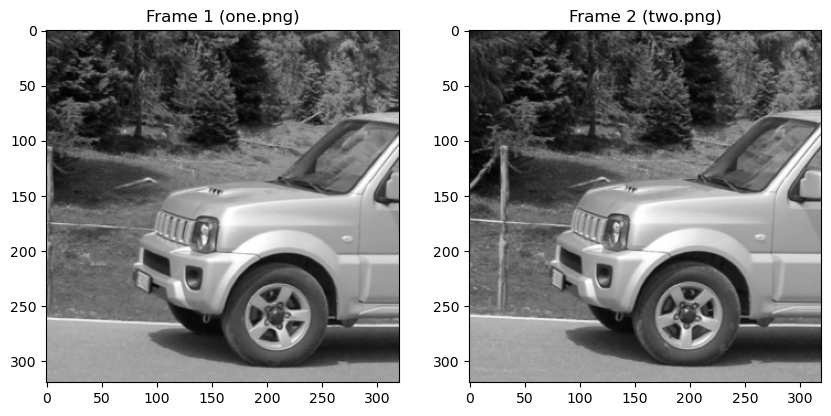

In [1]:
# Step 1: import and load frame
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import time

frame1 = cv2.imread("one_gray.png", cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread("two_gray.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(frame1, cmap="gray")
plt.title("Frame 1 (one.png)")

plt.subplot(1,2,2)
plt.imshow(frame2, cmap="gray")
plt.title("Frame 2 (two.png)")

In [2]:
# Step 2: Divide the image into blocks

block_size = 8
search_range = 8
height, width = frame1.shape

num_blocks_y = height // block_size
num_blocks_x = width // block_size

initial_step=4

In [3]:
# Step 3: Define functions

def calculate_psnr(original, predicted):
    mse = np.mean((original - predicted) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel_value = 255.0
    psnr = 20 * math.log10(max_pixel_value / math.sqrt(mse))
    return psnr

def compute_sad(block1, block2):
    return np.mean(np.abs(block1 - block2))

def full_search_motion_estimation(
        num_blocks_x, 
        num_blocks_y,
        search_range,
        block_size,
        height,
        width
    ):
    motion_vectors = np.zeros((num_blocks_x, num_blocks_y, 2))
    for y in range(num_blocks_y):
        for x in range(num_blocks_x):
            # Extract the block from the current frame (frame 2)
            block_current = frame2[y*block_size:(y+1)*block_size, x*block_size:(x+1)*block_size]

            # Initialize variables to track the best match
            min_sad = float('inf') # Positive infinity to find the smaller
            best_match = (0, 0)

            # Search within the search range in the reference frame (frame 1)
            for dy in range(-search_range, search_range+1):
                for dx in range(-search_range, search_range):
                    ref_y = y*block_size+dy
                    ref_x = x*block_size+dx
                    if ref_y < 0 or ref_y + block_size > height or ref_x < 0 or ref_x + block_size > width:
                        continue
                    
                    # Extract the block from the references frame
                    block_reference = frame1[ref_y:ref_y+block_size, ref_x:ref_x+block_size]

                    # Compute SAD between the current block and candidate reference block
                    sad = compute_sad(block_current, block_reference)

                    # Update the best match if this candidate block has a lower SAD
                    if sad < min_sad:
                        min_sad = sad
                        best_match = (dy, dx)

            # Store the motion vector for this block
            motion_vectors[y, x] = best_match
    return motion_vectors


def create_predicted_frame(
    num_blocks_x, 
    num_blocks_y,
    motion_vectors,
    block_size,
    height,
    width
):
    predicted_frame = np.zeros_like(frame2)

    for y in range(num_blocks_y):
        for x in range(num_blocks_x):
            # Get the motion vector for this block
            dy, dx = motion_vectors[y,x]

            # Calculate the position of the corresponding block in frame1
            ref_y = int(y*block_size + dy)
            ref_x = int(x*block_size + dx)

            # Ensure the references block is within bounds
            if ref_y >= 0 and ref_y + block_size <= height and ref_x >= 0 and ref_x + block_size <= width:
                # Copy the reference block to the predicted frame
                predicted_frame[y*block_size: (y+1)*block_size, x*block_size: (x+1)*block_size] = frame1[ref_y:ref_y+block_size, ref_x:ref_x+block_size]

    return predicted_frame

def create_residual_frame(original_frame, predicted_frame):
    residual_frame = original_frame - predicted_frame
    return residual_frame

def three_step_search(
        num_blocks_x, 
        num_blocks_y,
        block_size,
        height,
        width,
        initial_step=4
    ):
    height, width = frame1.shape
    num_blocks_y = height // block_size
    num_blocks_x = width // block_size
    
    motion_vectors = np.zeros((num_blocks_y, num_blocks_x, 2))  # Store motion vectors (dy, dx)

    for y in range(num_blocks_y):
        for x in range(num_blocks_x):
            # Extract the current block from frame 2
            block_current = frame2[y*block_size:(y+1)*block_size, x*block_size:(x+1)*block_size]

            # Initial best match as the center (0, 0 offset)
            best_match = (0, 0)
            min_sad = float('inf')

            step_size = initial_step  # Start with the initial large step size

            # Three-Step Search iterations (usually 3 iterations)
            while step_size >= 1:
                # Check 9 locations: center and its 8 neighbors in the search grid
                for dy in [-step_size, 0, step_size]:
                    for dx in [-step_size, 0, step_size]:
                        ref_y = y * block_size + best_match[0] + dy
                        ref_x = x * block_size + best_match[1] + dx

                        # Ensure the reference block is within bounds
                        if ref_y < 0 or ref_y + block_size > height or ref_x < 0 or ref_x + block_size > width:
                            continue

                        # Extract the reference block from frame1
                        block_reference = frame1[ref_y:ref_y+block_size, ref_x:ref_x+block_size]

                        # Compute SAD (Sum of Absolute Differences)
                        sad = np.sum(np.abs(block_current - block_reference))

                        # Update best match if we find a lower SAD
                        if sad < min_sad:
                            min_sad = sad
                            best_match = (best_match[0] + dy, best_match[1] + dx)

                # Reduce step size by half for the next iteration
                step_size //= 2

            # Store the motion vector (dy, dx) for this block
            motion_vectors[y, x] = best_match

    return motion_vectors


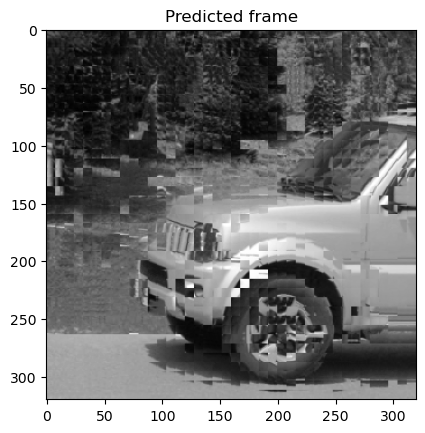

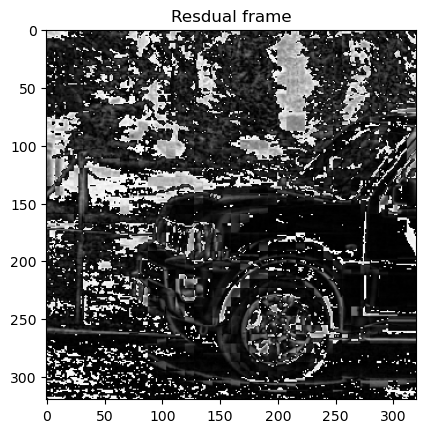

PSNR between actual frame and predicted frame: 29.222998931416736 dB
Runtime: 4.749370574951172 s


In [53]:
# Step 4 (Full Search): Create motion vectors, predicted, and residual frame4
# Compare runtime and psnr with three step search
start_time = time.time()
motion_vectors = full_search_motion_estimation(
    num_blocks_x,
    num_blocks_y,
    search_range,
    block_size,
    height,
    width
)
end_time = time.time()
runtime = end_time - start_time

predicted_frame = create_predicted_frame(
    num_blocks_x,
    num_blocks_y,
    motion_vectors,
    block_size,
    height,
    width
)

residual_frame = create_residual_frame(
    frame2,
    predicted_frame
)

np.save("residual_frame_full_search.npy", residual_frame)
np.save("predicted_frame_full_search.npy", predicted_frame)

# Display predicted frame
plt.imshow(predicted_frame, cmap="gray")
plt.title("Predicted frame")
plt.show()

# Display residual frame
plt.imshow(residual_frame, cmap="gray")
plt.title("Resdual frame")
plt.show()

# Show PSNR
psnr = calculate_psnr(frame2, predicted_frame)
print(f"PSNR between actual frame and predicted frame: {psnr} dB")
print(f"Runtime: {runtime} s")

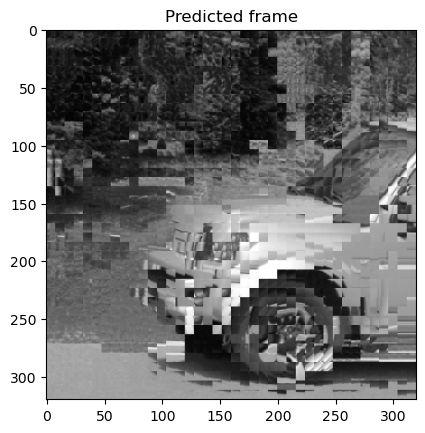

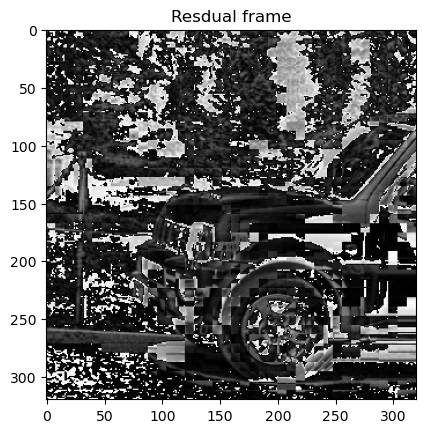

PSNR between actual frame and predicted frame: 28.59888524959291 dB
Runtime: 0.332169771194458 s


In [54]:
# Step 4 (Three Steps Search)
start_time = time.time()
motion_vectors = three_step_search(
    num_blocks_x,
    num_blocks_y,
    block_size,
    height,
    width,
    initial_step
)
end_time = time.time()
runtime = end_time - start_time
predicted_frame = create_predicted_frame(
    num_blocks_x,
    num_blocks_y,
    motion_vectors,
    block_size,
    height,
    width
)

residual_frame = create_residual_frame(
    frame2,
    predicted_frame
)

np.save("residual_frame_three_step.npy", residual_frame)
np.save("predicted_frame_three_step.npy", predicted_frame)

# Display predicted frame
plt.imshow(predicted_frame, cmap="gray")
plt.title("Predicted frame")
plt.show()

# Display residual frame
plt.imshow(residual_frame, cmap="gray")
plt.title("Resdual frame")
plt.show()

# Show PSNR
psnr = calculate_psnr(frame2, predicted_frame)
print(f"PSNR between actual frame and predicted frame: {psnr} dB")
print(f"Runtime: {runtime} s")

Search range: +-8 - Runtime: 4.8347179889678955 seconds


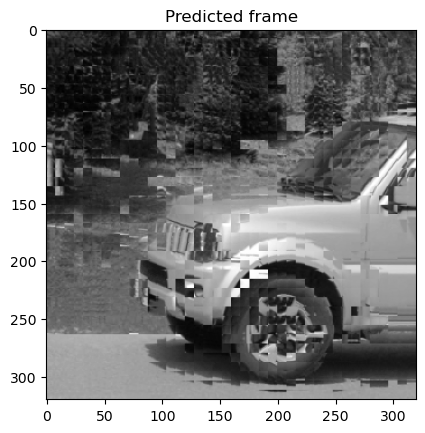

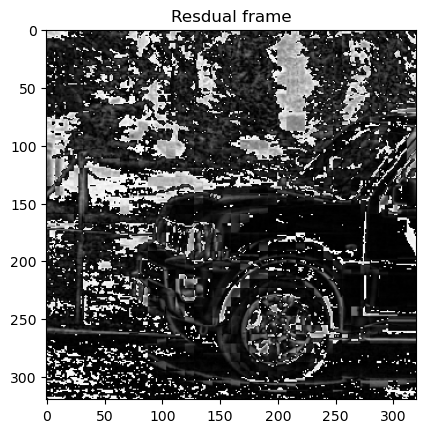

PSNR between actual frame and predicted frame: 29.222998931416736 dB
Search range: +-16 - Runtime: 4.844379663467407 seconds


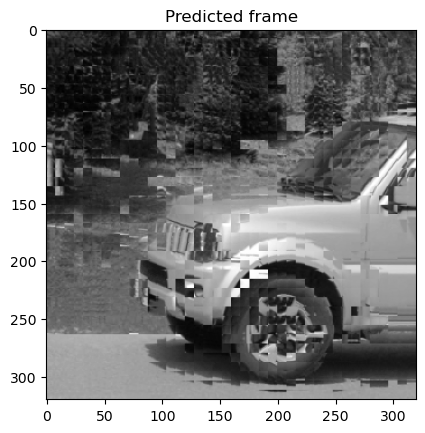

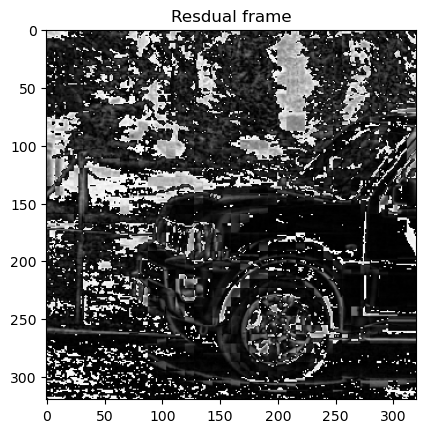

PSNR between actual frame and predicted frame: 29.222998931416736 dB
Search range: +-32 - Runtime: 5.06472635269165 seconds


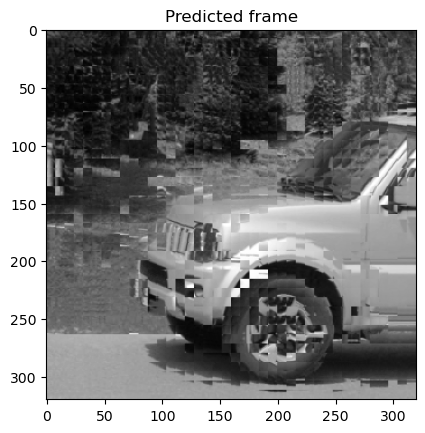

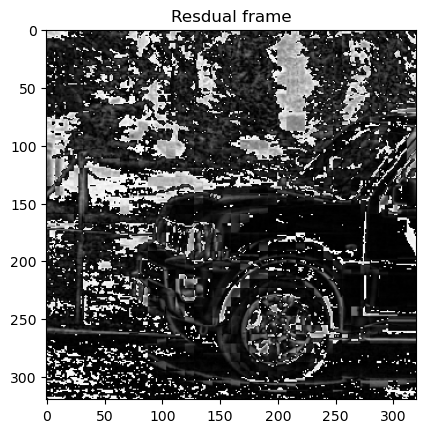

PSNR between actual frame and predicted frame: 29.222998931416736 dB


In [4]:
# Compare the results (in PSNR and runtime) with different search ranges ([+-8], [+-16], [+-32]).

search_ranges = [
    8, 16, 32
]

for i in range(len(search_ranges)):
    search_range_val = search_ranges[i]
    
    start_time = time.time()
    motion_vectors = full_search_motion_estimation(
        num_blocks_x,
        num_blocks_y,
        search_range,
        block_size,
        height,
        width
    )
    end_time = time.time()
    runtime = end_time - start_time
    print(f"Search range: +-{search_range_val} - Runtime: {runtime} seconds")

    predicted_frame = create_predicted_frame(
        num_blocks_x,
        num_blocks_y,
        motion_vectors,
        block_size,
        height,
        width
    )

    residual_frame = create_residual_frame(
        frame2,
        predicted_frame
    )

    # Display predicted frame
    plt.imshow(predicted_frame, cmap="gray")
    plt.title("Predicted frame")
    plt.show()

    # Display residual frame
    plt.imshow(residual_frame, cmap="gray")
    plt.title("Resdual frame")
    plt.show()

    # Show PSNR
    psnr = calculate_psnr(frame2, predicted_frame)
    print(f"PSNR between actual frame and predicted frame: {psnr} dB")


